# Parameterstudie: $\delta$, $\lambda$, die ADO-Skalierung und die Krylov-Dimension $m$

Das Hauptnotebook zeigt, *dass* das Gitter funktioniert.  Dieses hier zeigt, **wovon
es abhängt** — und wo die Grenzen liegen.

Vier Stellschrauben, und sie ziehen nicht alle in dieselbe Richtung:

| Knopf | wirkt auf | Zielkonflikt |
| :--- | :--- | :--- |
| $\delta$ (Lyapunov-Shift) | $p_{\mathrm{total}}$, $\mathrm{cond}(W)$, Shot-Bedarf | klein ist gut für $p$, schlecht für alles andere |
| $\lambda$ (Kopplung) | $\Vert P\Vert_2$, $\mathrm{cond}(W)$ | Physik, nicht frei wählbar |
| `scale_ados` | $\Vert P\Vert_2$, $\mathrm{cond}(W)$, Ablesbarkeit | rettet die Kontraktion, schadet der Ablesung |
| $m$ (Krylov) | Genauigkeit, Qubits | reiner Konvergenzparameter (Prop. 22) |

**Rechenaufwand.**  Die Parameter-Scans laufen bei Hierarchietiefe **2**
($\mathcal D_{\mathrm{tot}} = 720$), wo ein Punkt rund $2{,}8$ s kostet statt
$130$ s bei Tiefe 3.  Das qualitative Verhalten ist dasselbe; die aus dem
Hauptnotebook übernommenen Abschnitte rechnen weiterhin bei Tiefe 3.  Alle Scans
sind rein klassisch — kein Schaltkreis, keine Shots.

In [1]:
import os, sys, time, warnings
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt

from heom_gauge import (build_grid, regrid, heom_generator, contraction_gauge,
                        gauged_propagator, arnoldi, qutip_reference,
                        reference_trajectory, companion_baseline,
                        post_selection_curve, safe_norm2, lyapunov_schur)
from gauge_circuit import build_circuit, run_grid, run_grid_final

PIC, DATA = 'pictures', 'data'
for _d in (PIC, DATA): os.makedirs(_d, exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': .3,
                     'axes.titlesize': 10, 'legend.fontsize': 8})

_C_CM = 2.99792458e10
FS_TO_CM = 1e-15 * 2 * np.pi * _C_CM
KB_CM = 0.6950348004

N = 4
H_FMO = np.array([[12375.0, -87.7,   5.5,  -5.9],
                  [-87.7, 12495.0,  30.8,   8.2],
                  [5.5,      30.8, 12175.0, -53.4],
                  [-5.9,      8.2, -53.4, 12285.0]])
H_FMO = H_FMO - np.trace(H_FMO) / N * np.eye(N)
LAM_FMO, GAM_FMO, T_FMO = 3.0, 50.0, 300.0
MODEL = dict(H=H_FMO, lam=LAM_FMO, gamma=GAM_FMO, T_K=T_FMO,
             KB_CM=KB_CM, FS_TO_CM=FS_TO_CM)

rho0    = np.diag([1.0] + [0.0] * (N - 1))
dt_fs   = 10.0
dt_cm   = dt_fs * FS_TO_CM
N_STEPS = 100
t_fs    = np.arange(N_STEPS + 1) * dt_fs
D       = N * N
cols    = plt.cm.tab10(np.arange(10))

DEPTH_SCAN, M_SCAN = 2, 64          # schnell: n = 720
DEPTH_REF,  M_REF  = 3, 128         # wie im Hauptnotebook: n = 2640
DELTA_REF          = 0.02
EPS                = 0.01           # relative Genauigkeit in (P.1)

print(f"{N}-site FMO | Scans bei Tiefe {DEPTH_SCAN}, Referenz bei Tiefe {DEPTH_REF}")

4-site FMO | Scans bei Tiefe 2, Referenz bei Tiefe 3


## 1  Ein Parameterpunkt, rein klassisch

`probe` rechnet für einen Parametersatz alles aus, was das Gitter charakterisiert,
ohne einen einzigen Schaltkreis zu bauen.  Die beiden Größen, die später alles
bestimmen:

$$p_{\mathrm{total}}(n) = \frac{\Vert \tilde H_m^{\,n} y_0\Vert^2}{s^{2n}\Vert y_0\Vert^2},
\qquad
q_j = \bigl|\langle\chi_j|y_t\rangle\bigr|^2 = \Bigl(\frac{p_j}{\lambda_t\Vert r_j\Vert}\Bigr)^{2}$$

$p_{\mathrm{total}}$ ist der Anteil der Shots, die die Post-Selection überleben;
$q$ ist der Anteil *dieser* Shots, aus dem sich überhaupt ein Signal ablesen
lässt.  Der Shot-Bedarf für relative Genauigkeit $\varepsilon$ folgt daraus als

$$N_{\mathrm{shots}} \;\approx\; \frac{1}{4\,\varepsilon^{2}\,q_{\min}\,p_{\mathrm{total}}}\,. \tag{P.1}$$

In [2]:
from functools import lru_cache
from heom_gauge import lyapunov_schur

@lru_cache(maxsize=4)
def _generator(lam, gamma, T_K, depth, scale_ados):
    """L und seine Schur-Zerlegung -- beide haengen NICHT von delta ab.

    Bartels-Stewart loest (LYAP) ueber die Schur-Form von L^dagger - delta I,
    und der Shift aendert nur die Diagonale, nicht die Schur-Vektoren.  Einmal
    zerlegen macht einen delta-Sweep rund 13x schneller (gemessen: 29.8 s -> 2.3 s
    je Punkt bei n = 720).
    """
    M2 = dict(MODEL); M2.update(lam=lam, gamma=gamma, T_K=T_K)
    L, info = heom_generator(depth=depth, Nk=1, scale_ados=scale_ados, **M2)
    return L, info, lyapunov_schur(L)


def probe(*, delta, lam=LAM_FMO, gamma=GAM_FMO, T_K=T_FMO, depth=DEPTH_SCAN,
          m=M_SCAN, scale_ados=False, n_steps=N_STEPS, eps=EPS, eps_abs=0.01,
          floor=0.05):
    """Alle klassischen Kenngroessen eines Parameterpunkts -- kein Schaltkreis.

    `eps`     relative Genauigkeit auf den Populationen, geht in (P.1) ein
    `eps_abs` absolute Genauigkeit (0.01 = 1 Prozentpunkt), geht in (P.2) ein
    `floor`   nur Populationen mit p_j(t) >= floor * max_j p_j(t) zaehlen fuer
              (P.1); ohne das divergiert die relative Forderung dort, wo eine
              Population durch null geht (bei t=0 sind drei davon exakt null).
    """
    L, info, sf = _generator(lam, gamma, T_K, depth, scale_ados)
    n = info['n']
    omega = float(np.linalg.eigvalsh(0.5 * (L + L.conj().T)).max())   # num. Abszisse
    try:
        Wh, Wih, gi = contraction_gauge(L, delta=delta, schur_factor=sf)
    except np.linalg.LinAlgError as e:
        return dict(delta=delta, lam=lam, scaled=scale_ados, n=n, omega=omega,
                    failed=str(e)[:45], condW=np.nan, normP=np.nan, normPt=np.nan,
                    lamW_max=np.nan, lamW_min=np.nan, q_worst=np.nan, amp=np.nan,
                    p_end=np.nan, shots=np.nan, shots_abs=np.nan, y0norm=np.nan,
                    trustworthy=False)
    Pt, P = gauged_propagator(L, dt_cm, Wh, Wih)

    x0 = np.zeros(n, complex); x0[:D] = rho0.flatten(order='F')
    xt0 = Wh @ x0
    Hm, Qm = arnoldi(Pt, xt0, m); m = Hm.shape[0]
    R  = (Wih @ Qm)[:D, :]
    y0 = np.zeros(m, complex); y0[0] = np.linalg.norm(xt0)
    s  = float(np.linalg.norm(Hm, 2))
    rows = [R[j + N * j, :] for j in range(N)]
    nr = np.array([np.linalg.norm(r) for r in rows])
    chi = [np.conj(r) / np.linalg.norm(r) for r in rows]

    # Zwei Shot-Metriken, beide je Zeitpunkt ausgewertet und dann ueber t
    # maximiert -- NICHT min(q) und min(p) aus verschiedenen Zeiten kombiniert.
    #
    #   (P.1) relativ:  eps = dp_j/p_j = 1/(2 sqrt(N p_t q_j))
    #                    ->  N = 1/(4 eps^2 q_j p_t)
    #   (P.2) absolut:  dp_j = ||r_j|| lambda_t / (2 sqrt(N p_t))
    #                    ->  N = A_j^2/(4 eps_abs^2 p_t),  A_j = ||r_j|| lambda_t
    #
    # In (P.1) steht q, in (P.2) kuerzt es sich heraus.  Das ist kein Widerspruch:
    # eine Population nahe null ist absolut leicht, relativ beliebig schwer.
    y, p_tot, q_min, amp, N_rel, N_abs = y0.copy(), [], [], [], [], []
    for t in range(n_steps + 1):
        nt = np.linalg.norm(y)
        p_t = (nt / (s ** t * np.linalg.norm(y0))) ** 2
        lam_t = np.linalg.norm(y0) * s ** t * np.sqrt(p_t)
        yd = y / nt
        qq = np.array([abs(np.vdot(c, yd)) ** 2 for c in chi])
        pj = nr * lam_t * np.sqrt(qq)                     # die Populationen selbst
        big = pj >= floor * pj.max()                      # nur signaltragende
        p_tot.append(p_t); amp.append((nr * lam_t).max())
        q_min.append(qq[big].min() if big.any() else np.nan)
        N_rel.append(1.0 / (4 * eps ** 2 * qq[big].min() * p_t) if big.any() else np.nan)
        N_abs.append(((nr * lam_t).max()) ** 2 / (4 * eps_abs ** 2 * p_t))
        y = Hm @ y
    p_tot, q_min = np.array(p_tot), np.array(q_min)
    amp, N_rel, N_abs = np.array(amp), np.array(N_rel), np.array(N_abs)

    return dict(delta=delta, lam=lam, scaled=scale_ados, n=n, m=m, omega=omega,
                normP=safe_norm2(P), normPt=safe_norm2(Pt), normHm=s,
                bound=float(np.exp(delta * dt_cm)),
                condW=gi['cond'], lamW_max=gi['eig_max'], lamW_min=gi['eig_min'],
                y0norm=float(np.linalg.norm(y0)),
                p_total=p_tot, p_end=p_tot[-1], q_min=q_min,
                q_worst=float(np.nanmin(q_min)), amp=float(np.nanmax(amp)),
                shots=float(np.nanmax(N_rel)), shots_abs=float(np.nanmax(N_abs)),
                trustworthy=bool(safe_norm2(Pt) <= np.exp(delta * dt_cm) * (1 + 1e-6)),
                Hm=Hm, R=R, y0=y0, s=s, failed=None)


t0 = time.time(); ref = probe(delta=DELTA_REF); dt_probe = time.time() - t0
t0 = time.time(); probe(delta=0.1);              dt_warm = time.time() - t0
print(f"erster Parameterpunkt: {dt_probe:.1f} s (n = {ref['n']}, inkl. Schur), "
      f"jedes weitere delta: {dt_warm:.1f} s")
print(f"  ||P||={ref['normP']:.4f}  ||P~||={ref['normPt']:.6f}  "
      f"cond(W)={ref['condW']:.2e}  p(100)={ref['p_end']:.4f}  q_min={ref['q_worst']:.2e}")
print(f"  -> (P.1) {ref['shots']:.2e} Shots fuer {EPS:.0%} relativ, "
      f"(P.2) {ref['shots_abs']:.2e} Shots fuer 1 Prozentpunkt absolut")

erster Parameterpunkt: 18.5 s (n = 720, inkl. Schur), jedes weitere delta: 10.5 s
  ||P||=10.6599  ||P~||=1.000038  cond(W)=2.65e+08  p(100)=0.7976  q_min=1.82e-04
  -> (P.1) 1.42e+07 Shots fuer 1% relativ, (P.2) 8.97e+03 Shots fuer 1 Prozentpunkt absolut


## 2  Der Erzeuger: $\Vert P\Vert_2$ gegen Kopplung und numerische Abszisse

Die Operatornorm des Ein-Schritt-Propagators ist das, was die Sz.-Nagy-Dilatation
als Skalierungsfaktor $s$ erzwingt.  Sie hängt am transienten Wachstum, und das
wird von der **numerischen Abszisse** $\omega(\mathcal L) = \lambda_{\max}\bigl(\tfrac12(\mathcal L+\mathcal L^\dagger)\bigr)$
gesteuert:

$$\Vert P\Vert_2 = \Vert e^{\mathcal L\Delta\tau}\Vert_2 \;\lesssim\; e^{\omega(\mathcal L)\,\Delta\tau}$$

Das rechte Panel prüft die Behauptung aus dem Theorieteil, $\omega \approx \lambda/2$.

lambda-Scan: 184 s


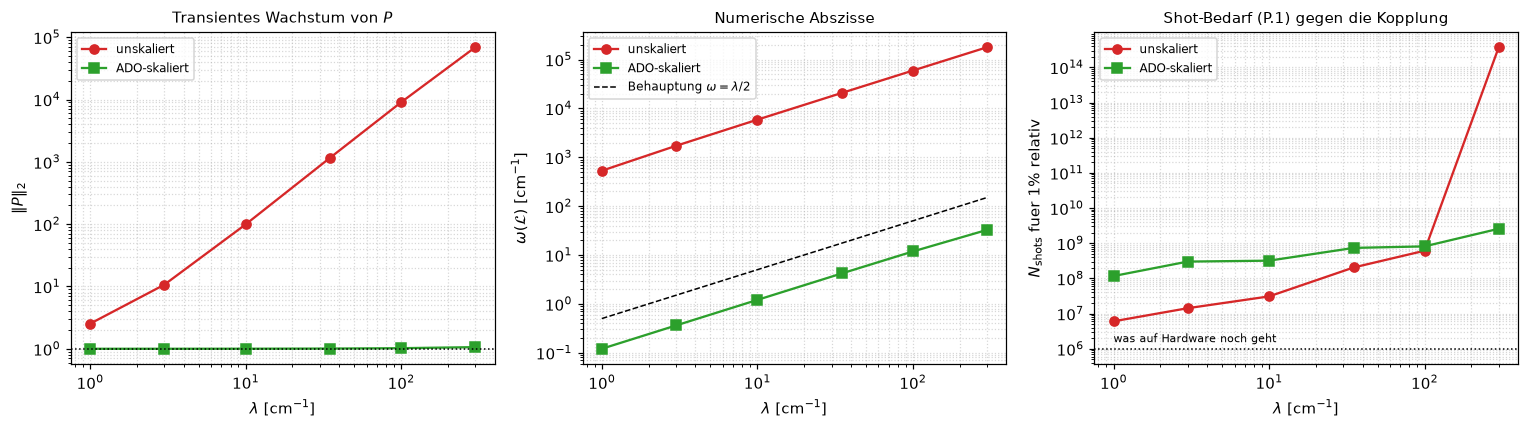

  omega(L) ~ lambda^1.00   (Behauptung im Theorieteil: linear, omega = lambda/2)
  omega/lambda bei lambda=100: 594.5 (unskaliert), 0.118 (ADO-skaliert)
  ADO-skaliert: omega ~ lambda^0.97, Vorfaktor 0.118
  -> LINEAR stimmt in beiden Faellen, der Faktor 1/2 in KEINEM: unskaliert
     595, skaliert 0.12.  Die Skalierung symmetrisiert die Auf- und
     Ab-Kopplung zwischen den ADOs und drueckt den hermiteschen Anteil
     dadurch um rund vier Groessenordnungen -- das ist der Grund, warum sie
     ||P|| ueberhaupt auf 1 bringt.


In [3]:
LAMS = np.array([1.0, 3.0, 10.0, 35.0, 100.0, 300.0])

t0 = time.time()
scanL = {sc: [probe(delta=DELTA_REF, lam=l, scale_ados=sc) for l in LAMS]
         for sc in (False, True)}
print(f"lambda-Scan: {time.time()-t0:.0f} s")

fig, ax = plt.subplots(1, 3, figsize=(14, 4))

# --- Plot 0: transientes Wachstum von P ---
for sc, c, mk in ((False, 'C3', 'o'), (True, 'C2', 's')):
    r = scanL[sc]
    ax[0].loglog(LAMS, [x['normP'] for x in r], mk + '-', color=c,
                 label='unskaliert' if not sc else 'ADO-skaliert')
ax[0].axhline(1, color='k', ls=':', lw=1)
ax[0].set_xlabel(r'$\lambda$ [cm$^{-1}$]')
ax[0].set_ylabel(r'$\Vert P\Vert_2$')
ax[0].set_title(r'Transientes Wachstum von $P$')
ax[0].grid(True, which="both", ls=":", alpha=0.5)
ax[0].legend()

# --- Plot 1: Numerische Abszisse ---
for sc, c, mk in ((False, 'C3', 'o'), (True, 'C2', 's')):
    r = scanL[sc]
    ax[1].loglog(LAMS, [x['omega'] for x in r], mk + '-', color=c,
                 label='unskaliert' if not sc else 'ADO-skaliert')
om = np.array([x['omega'] for x in scanL[False]])
ax[1].plot(LAMS, LAMS / 2, 'k--', lw=1, label=r'Behauptung $\omega=\lambda/2$')
ax[1].set_xlabel(r'$\lambda$ [cm$^{-1}$]')
ax[1].set_ylabel(r'$\omega(\mathcal{L})$ [cm$^{-1}$]')
ax[1].set_title('Numerische Abszisse')
ax[1].grid(True, which="both", ls=":", alpha=0.5)
ax[1].legend()

# --- Plot 2: Shot-Bedarf gegen die Kopplung ---
# (P.1) mit q_min und p_total aus DEMSELBEN Zeitpunkt, ueber t maximiert.
for sc, c, mk in ((False, 'C3', 'o'), (True, 'C2', 's')):
    r = scanL[sc]
    ax[2].loglog(LAMS, [x['shots'] for x in r], mk + '-', color=c,
                 label='unskaliert' if not sc else 'ADO-skaliert')
ax[2].axhline(1e6, color='k', ls=':', lw=1)
ax[2].text(LAMS[0], 1.3e6, 'was auf Hardware noch geht', fontsize=7, va='bottom')
ax[2].set_xlabel(r'$\lambda$ [cm$^{-1}$]')
ax[2].set_ylabel(rf'$N_{{\mathrm{{shots}}}}$ fuer {EPS:.0%} relativ')
ax[2].set_title(r'Shot-Bedarf (P.1) gegen die Kopplung')
ax[2].grid(True, which="both", ls=":", alpha=0.5)
ax[2].legend()

fig.tight_layout()
fig.savefig(f'{PIC}/param_P_vs_lambda.png', dpi=160)
plt.show()

sl = np.polyfit(np.log(LAMS[2:]), np.log(om[2:]), 1)[0]
print(f"  omega(L) ~ lambda^{sl:.2f}   (Behauptung im Theorieteil: linear, omega = lambda/2)")
k100 = LAMS.tolist().index(100.0)
oms = np.array([x['omega'] for x in scanL[True]])
print(f"  omega/lambda bei lambda=100: {om[k100]/100:.1f} (unskaliert), "
      f"{oms[k100]/100:.3f} (ADO-skaliert)")
sls = np.polyfit(np.log(LAMS[2:]), np.log(oms[2:]), 1)[0]
print(f"  ADO-skaliert: omega ~ lambda^{sls:.2f}, Vorfaktor {oms[k100]/100:.3f}")
print("  -> LINEAR stimmt in beiden Faellen, der Faktor 1/2 in KEINEM: unskaliert\n"
      "     595, skaliert 0.12.  Die Skalierung symmetrisiert die Auf- und\n"
      "     Ab-Kopplung zwischen den ADOs und drueckt den hermiteschen Anteil\n"
      "     dadurch um rund vier Groessenordnungen -- das ist der Grund, warum sie\n"
      "     ||P|| ueberhaupt auf 1 bringt.")

## 3  Die Eichung: $\mathrm{cond}(W)$ und $\Vert W\Vert_2$

$W$ ist hermitesch und positiv definit, also ist $\Vert W\Vert_2 = \lambda_{\max}(W)$ —
Operatornorm und größter Eigenwert sind hier **dieselbe Zahl**.  Statt beide zu
plotten, zeige ich $\lambda_{\max}$ und $\lambda_{\min}$ zusammen: ihr Verhältnis
*ist* $\mathrm{cond}(W)$, und man sieht direkt, welcher der beiden Ränder wandert.

Der Theorieteil führt das auf die Neumann-Reihe zurück,
$W=\sum_k e^{-2k\delta\Delta\tau}(P^\dagger)^kQP^k$: bei kleinem $\delta$ fällt der
Dämpfungsterm langsam, die Summe wird groß, $\lambda_{\max}$ wächst.  Die
gestrichelte Gerade prüft das erwartete $1/\delta$.

In [4]:
# Der delta-Sweep.  Reicht bis delta = 50, damit das Minimum des Shot-Bedarfs
# im Inneren liegt und nicht am rechten Rand klebt.  Dank des Schur-Caches in
# `_generator` kostet jeder weitere delta-Punkt nur noch die Dreiecksgleichung.
DELTAS = np.array([1e-5, 1e-4, 1e-3, 1e-2, 0.1, 0.3, 1.0, 3.0,
                   10.0, 20.0, 50.0, 100.0, 200.0])

t0 = time.time()
scanD = {sc: [probe(delta=d, scale_ados=sc) for d in DELTAS]   # delta innen: Cache haelt
         for sc in (False, True)}
print(f"delta-Scan: {time.time()-t0:.0f} s fuer {2*len(DELTAS)} Punkte")

fail = [(d, sc) for sc in (False, True) for d, x in zip(DELTAS, scanD[sc])
        if x.get('failed')]
print(f"  keine Eichung gefunden bei: {fail if fail else 'nirgends'}")

delta-Scan: 233 s fuer 26 Punkte
  keine Eichung gefunden bei: nirgends


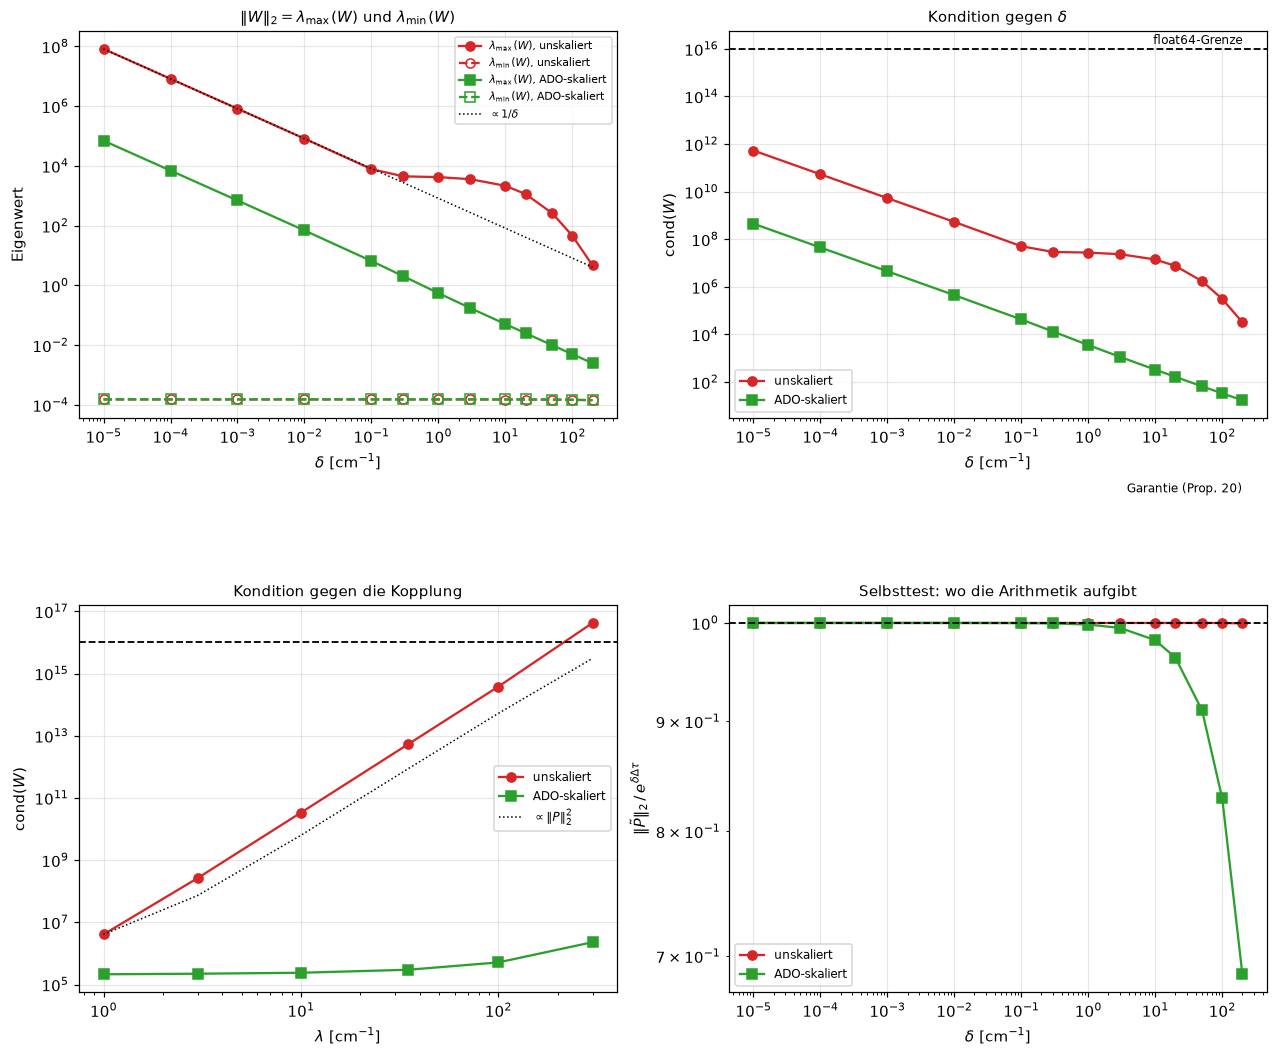

In [5]:
# 1. Höhe vergrößern oder Layout-Engine nutzen
fig, ax = plt.subplots(2, 2, figsize=(11.5, 9.5), layout='constrained')

# (a) Eigenwertraender von W gegen delta
for sc, c, mk, ls in ((False, 'C3', 'o', '-'), (True, 'C2', 's', '-')):
    r = scanD[sc]
    lab = 'unskaliert' if not sc else 'ADO-skaliert'
    ax[0, 0].loglog(DELTAS, [x['lamW_max'] for x in r], mk + ls, color=c,
                    label=rf'$\lambda_{{\max}}(W)$, {lab}')
    ax[0, 0].loglog(DELTAS, [x['lamW_min'] for x in r], mk + '--', color=c,
                    mfc='none', label=rf'$\lambda_{{\min}}(W)$, {lab}')

# Asymptotische 1/delta Referenzlinie (bereinigt)
ax[0, 0].loglog(DELTAS, scanD[False][0]['lamW_max'] * (DELTAS[0] / DELTAS), 'k:',
                lw=1, label=r'$\propto 1/\delta$')
ax[0, 0].set_xlabel(r'$\delta$ [cm$^{-1}$]')
ax[0, 0].set_ylabel('Eigenwert')
ax[0, 0].set_title(r'$\Vert W\Vert_2=\lambda_{\max}(W)$ und $\lambda_{\min}(W)$')
ax[0, 0].legend(fontsize=7)

# (b) cond(W) gegen delta
for sc, c, mk in ((False, 'C3', 'o'), (True, 'C2', 's')):
    ax[0, 1].loglog(DELTAS, [x['condW'] for x in scanD[sc]], mk + '-', color=c,
                    label='unskaliert' if not sc else 'ADO-skaliert')
ax[0, 1].axhline(1e16, color='k', ls='--', lw=1.2)
ax[0, 1].text(DELTAS[-1], 1.6e16, 'float64-Grenze', ha='right', fontsize=8)
ax[0, 1].set_xlabel(r'$\delta$ [cm$^{-1}$]')
ax[0, 1].set_ylabel(r'$\mathrm{cond}(W)$')
ax[0, 1].set_title(r'Kondition gegen $\delta$')
ax[0, 1].legend()

# (c) cond(W) gegen lambda
for sc, c, mk in ((False, 'C3', 'o'), (True, 'C2', 's')):
    ax[1, 0].loglog(LAMS, [x['condW'] for x in scanL[sc]], mk + '-', color=c,
                    label='unskaliert' if not sc else 'ADO-skaliert')
nP = np.array([x['normP'] for x in scanL[False]])
ax[1, 0].loglog(LAMS, (nP / nP[0])**2 * scanL[False][0]['condW'], 'k:', lw=1,
                label=r'$\propto\Vert P\Vert_2^{2}$')
ax[1, 0].axhline(1e16, color='k', ls='--', lw=1.2)
ax[1, 0].set_xlabel(r'$\lambda$ [cm$^{-1}$]')
ax[1, 0].set_ylabel(r'$\mathrm{cond}(W)$')
ax[1, 0].set_title(r'Kondition gegen die Kopplung')
ax[1, 0].legend()

# (d) Selbsttest: ||P~|| gegen Schranke
for sc, c, mk in ((False, 'C3', 'o'), (True, 'C2', 's')):
    r = scanD[sc]
    rel = [x['normPt'] / x['bound'] for x in r]
    ax[1, 1].loglog(DELTAS, rel, mk + '-', color=c,
                    label='unskaliert' if not sc else 'ADO-skaliert')
ax[1, 1].axhline(1, color='k', ls='--', lw=1.2)
ax[1, 1].text(DELTAS[-1], 1.15, 'Garantie (Prop. 20)', ha='right', fontsize=8)
ax[1, 1].set_xlabel(r'$\delta$ [cm$^{-1}$]')
ax[1, 1].set_ylabel(r'$\Vert\tilde P\Vert_2\,/\,e^{\delta\Delta\tau}$')
ax[1, 1].set_title('Selbsttest: wo die Arithmetik aufgibt')
ax[1, 1].legend()

# fig.tight_layout() entfällt dank layout='constrained'
fig.savefig(f'{PIC}/param_gauge.png', dpi=160, bbox_inches='tight')
plt.show()

## 4  Der Zielkonflikt: Erfolgswahrscheinlichkeit gegen Ablesbarkeit

Hier steckt die eigentliche Erkenntnis dieser Studie.  Maßgeblich ist

$$N_{\mathrm{shots}} \;\approx\; \frac{1}{4\,\varepsilon^{2}\,q_j\,p_{\mathrm{total}}(t)} \tag{P.1}$$

für **relative** Genauigkeit $\varepsilon$ auf der Population $p_j$.  Sie folgt in einer
Zeile: der absolute Fehler ist $\delta p_j = \Vert r_j\Vert\lambda_t/(2\sqrt{N p_t})$, die
Population selbst ist $p_j = \Vert r_j\Vert\lambda_t\sqrt{q_j}$, also

$$\varepsilon \;=\; \frac{\delta p_j}{p_j} \;=\; \frac{\Vert r_j\Vert\lambda_t}{2\sqrt{N p_t}}\cdot\frac{1}{\Vert r_j\Vert\lambda_t\sqrt{q_j}} \;=\; \frac{1}{2\sqrt{N\,p_t\,q_j}} \;\Longrightarrow\; N = \frac{1}{4\varepsilon^2 q_j p_t}.$$

$\delta$ wirkt auf die beiden Faktoren im Nenner **gegenläufig**:

* $p_{\mathrm{total}} \propto e^{-2\delta T}$ — kleines $\delta$ ist gut, die
  Post-Selection verwirft dann fast nichts;
* $q_j$, der Ablese-Überlapp — kleines $\delta$ ist schlecht, denn
  $\mathrm{cond}(W)\propto1/\delta$ treibt $\Vert y_0\Vert=\Vert W^{1/2}x_0\Vert$
  hoch, und $q\propto1/\lambda_t^2$ fällt quadratisch mit.

Das Produkt $q\,p$ hat deshalb ein Maximum bei mittlerem $\delta$, und $N$ dort ein
**Minimum**.  Genau diesen Punkt will man wählen — nicht „$\delta$ so klein wie möglich",
wie ich zunächst angenommen hatte.

Zwei Feinheiten, die bei der Auswertung leicht schiefgehen:

1. $q_j$ und $p_{\mathrm{total}}$ müssen aus **demselben** Zeitpunkt kommen und das
   Ergebnis über $t$ maximiert werden.  Nimmt man $\min_t q$ und $\min_t p$ getrennt,
   kombiniert man zwei Zeiten, die nichts miteinander zu tun haben.
2. (P.1) divergiert dort, wo eine Population durch null geht — bei $t=0$ sind hier drei
   davon exakt null, und relative Genauigkeit auf einer Null ist keine sinnvolle
   Forderung.  `probe` wertet (P.1) deshalb nur auf den signaltragenden Populationen
   aus, $p_j(t)\ge 0{,}05\max_j p_j(t)$.

Zum Vergleich steht daneben die **absolute** Variante

$$N_{\mathrm{shots}} \;=\; \frac{A_j^{\,2}}{4\,\varepsilon_{\mathrm{abs}}^{2}\,p_{\mathrm{total}}(t)},
\qquad A_j = \Vert r_j\Vert\,\lambda_t . \tag{P.2}$$

Dort kürzt sich $q$ heraus. Das ist kein Widerspruch zu (P.1), sondern dieselbe Aussage
aus zwei Blickwinkeln: eine Population nahe null ist **absolut** leicht zu messen und
**relativ** beliebig schwer.

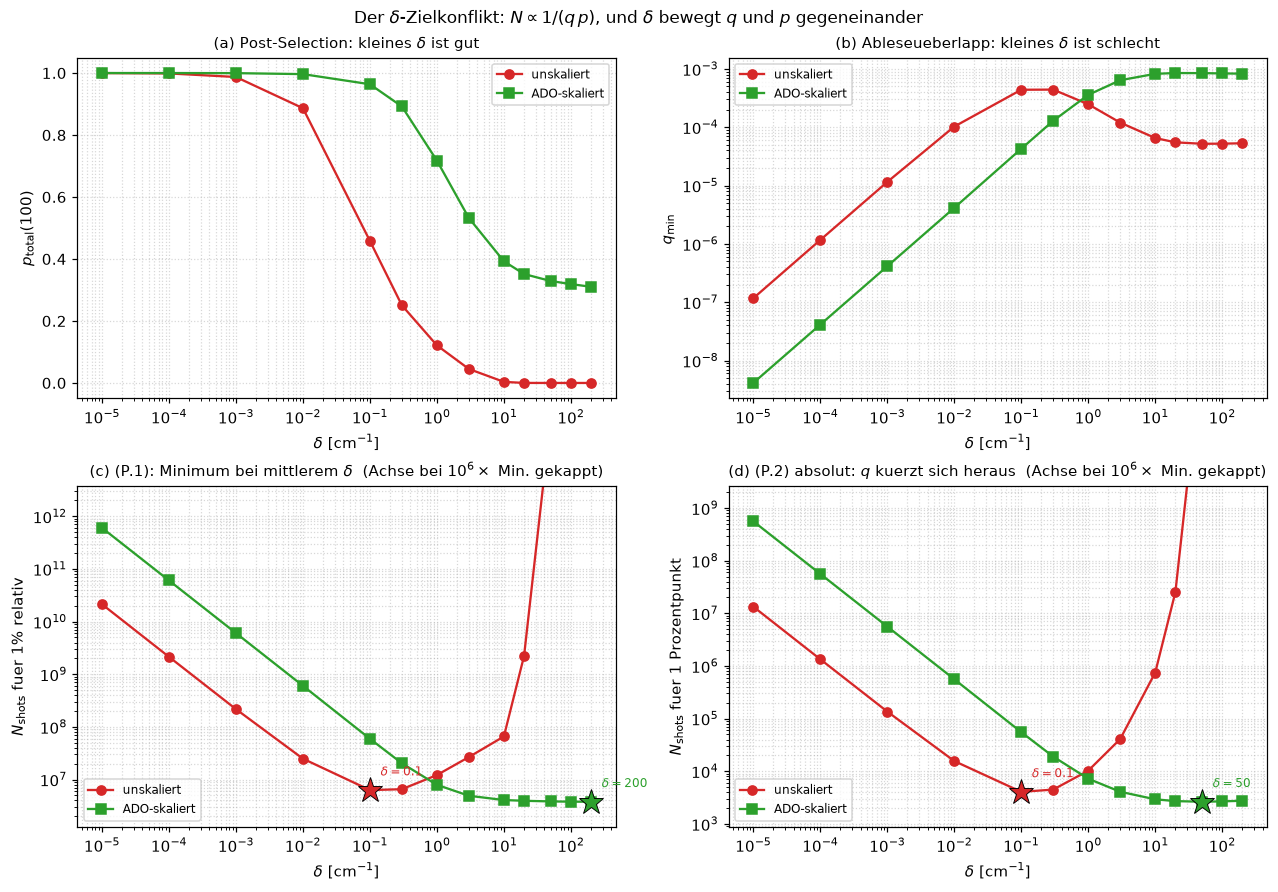

   delta |   p(100)      q_min    N (P.1)    N (P.2) |    p(100)      q_min    N (P.1)    N (P.2)
         |   ------------ unskaliert ------------    |   ----------- ADO-skaliert -----------   
   1e-05 |   0.9999   1.17e-07   2.14e+10   1.34e+07 |   1.0000   4.13e-09   6.06e+11   5.61e+08
  0.0001 |   0.9987   1.17e-06   2.14e+09   1.34e+06 |   1.0000   4.13e-08   6.06e+10   5.61e+07
   0.001 |   0.9873   1.15e-05   2.17e+08   1.36e+05 |   0.9997   4.13e-07   6.05e+09   5.61e+06
    0.01 |   0.8866   1.03e-04   2.49e+07   1.56e+04 |   0.9965   4.15e-06   6.04e+08   5.60e+05
     0.1 |   0.4584   4.39e-04   6.29e+06   4.06e+03 |   0.9638   4.27e-05   5.95e+07   5.54e+04
     0.3 |   0.2505   4.42e-04   6.54e+06   4.48e+03 |   0.8922   1.29e-04   2.04e+07   1.90e+04
       1 |   0.1214   2.48e-04   1.21e+07   1.02e+04 |   0.7175   3.59e-04   7.93e+06   7.21e+03
       3 |   0.0451   1.20e-04   2.67e+07   4.08e+04 |   0.5322   6.39e-04   4.91e+06   4.08e+03
      10 |   0.0035   6.53e-0

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(11.5, 8), layout='constrained')

for sc, c, mk in ((False, 'C3', 'o'), (True, 'C2', 's')):
    r = scanD[sc]
    lab = 'unskaliert' if not sc else 'ADO-skaliert'
    ax[0, 0].semilogx(DELTAS, [x['p_end'] for x in r], mk + '-', color=c, label=lab)
    ax[0, 1].loglog(DELTAS, [x['q_worst'] for x in r], mk + '-', color=c, label=lab)
    ax[1, 0].loglog(DELTAS, [x['shots'] for x in r], mk + '-', color=c, label=lab)
    ax[1, 1].loglog(DELTAS, [x['shots_abs'] for x in r], mk + '-', color=c, label=lab)

# (a) Post-Selection
ax[0, 0].set_ylim(-0.05, 1.05)
ax[0, 0].set_ylabel(r'$p_{\mathrm{total}}(100)$')
ax[0, 0].set_title(r'(a) Post-Selection: kleines $\delta$ ist gut')

# (b) Ableseueberlapp
ax[0, 1].set_ylabel(r'$q_{\min}$')
ax[0, 1].set_title(r'(b) Ableseueberlapp: kleines $\delta$ ist schlecht')

# (c) und (d) Shot-Bedarf, jeweils mit markiertem Minimum
for A, key, ttl, yl in ((ax[1, 0], 'shots',
                         rf'(c) (P.1): Minimum bei mittlerem $\delta$',
                         rf'$N_{{\mathrm{{shots}}}}$ fuer {EPS:.0%} relativ'),
                        (ax[1, 1], 'shots_abs',
                         r'(d) (P.2) absolut: $q$ kuerzt sich heraus',
                         r'$N_{\mathrm{shots}}$ fuer 1 Prozentpunkt')):
    for sc, c in ((False, 'C3'), (True, 'C2')):
        sh = np.array([x[key] for x in scanD[sc]], float)
        if np.all(np.isnan(sh)):
            continue
        k = int(np.nanargmin(sh))
        A.plot(DELTAS[k], sh[k], '*', ms=17, color=c, mec='k', mew=.6, zorder=5)
        A.annotate(rf'$\delta={DELTAS[k]:g}$', (DELTAS[k], sh[k]),
                   textcoords='offset points', xytext=(7, 9), fontsize=8, color=c)
    # Ohne Deckel bestimmt der unskalierte Ausreisser bei delta = 200 (bis 1e38)
    # die ganze Achse und drueckt das Minimum an den unteren Rand.
    lo = min(np.nanmin([x[key] for x in scanD[sc]]) for sc in (False, True))
    A.set_ylim(lo / 3, lo * 1e6)
    A.set_ylabel(yl)
    A.set_title(ttl + r'  (Achse bei $10^6\times$ Min. gekappt)')

for A in ax.ravel():
    A.set_xlabel(r'$\delta$ [cm$^{-1}$]')
    A.grid(True, which='both', ls=':', alpha=.5)
    A.legend(fontsize=8)

fig.suptitle(r'Der $\delta$-Zielkonflikt: $N \propto 1/(q\,p)$, und $\delta$ '
             r'bewegt $q$ und $p$ gegeneinander', fontsize=11)
fig.savefig(f'{PIC}/param_tradeoff.png', dpi=160, bbox_inches='tight')
plt.show()

hdr = f"{'delta':>8s} | {'p(100)':>8s} {'q_min':>10s} {'N (P.1)':>10s} {'N (P.2)':>10s}"
print(hdr + " | " + hdr.split('|')[1])
print(f"{'':>8s} | {'------------ unskaliert ------------':^41s}"
      f" | {'----------- ADO-skaliert -----------':^41s}")
for k, d in enumerate(DELTAS):
    a, b = scanD[False][k], scanD[True][k]
    print(f"{d:8g} | {a['p_end']:8.4f} {a['q_worst']:10.2e} {a['shots']:10.2e} "
          f"{a['shots_abs']:10.2e} | {b['p_end']:8.4f} {b['q_worst']:10.2e} "
          f"{b['shots']:10.2e} {b['shots_abs']:10.2e}")

# Liegt das Minimum im Inneren, oder klebt es am Rand?  Ein Minimum am rechten
# Rand ist nur dann ein Problem, wenn die Kurve dort noch faellt; laeuft sie in
# ein Plateau, ist "immer groesser" die richtige Antwort und der Bereich reicht.
for sc, nm in ((False, 'unskaliert'), (True, 'ADO-skaliert')):
    sh = np.array([x['shots'] for x in scanD[sc]], float)
    k = int(np.nanargmin(sh))
    if 0 < k < len(DELTAS) - 1:
        urteil = 'INNEN -- das ist die Wahl'
    else:
        fall = 1 - sh[-1] / sh[-2]
        urteil = (f'am Rand, aber Plateau ({fall:+.1%} im letzten Schritt) '
                  f'-- groesser bringt nichts mehr' if abs(fall) < 0.1 else
                  f'AM RAND und noch fallend ({fall:+.1%}) -- Bereich erweitern!')
    print(f"\n  {nm:13s}: (P.1)-Minimum bei delta = {DELTAS[k]:g}, "
          f"{sh[k]:.2e} Shots  [{urteil}]")

### 4b  Beide Achsen zugleich: $N_{\mathrm{shots}}(\delta,\lambda)$

Die Schnitte oben zeigen $\delta$ bei festem $\lambda=3$ und $\lambda$ bei festem
$\delta=0{,}02$.  Interessant ist, ob das $\delta$-Minimum *wandert*, wenn die Kopplung
steigt — ob man also für jede Kopplung neu eichen muss oder ob eine Wahl für alle taugt.

Aufgetragen ist $\log_{10}N_{\mathrm{shots}}$ nach (P.1).  Löcher in der Fläche sind
Parameterpunkte, an denen **keine** Eichung existiert: die abgeschnittene Hierarchie ist
dort echt instabil (Eigenwerte mit $\mathrm{Re}>0$), und dann gibt es kein
positiv definites $W$ — kein numerisches Problem, sondern ein strukturelles.

3D-Scan aus data/scan3d.npz geladen (zum Neurechnen die Datei loeschen)


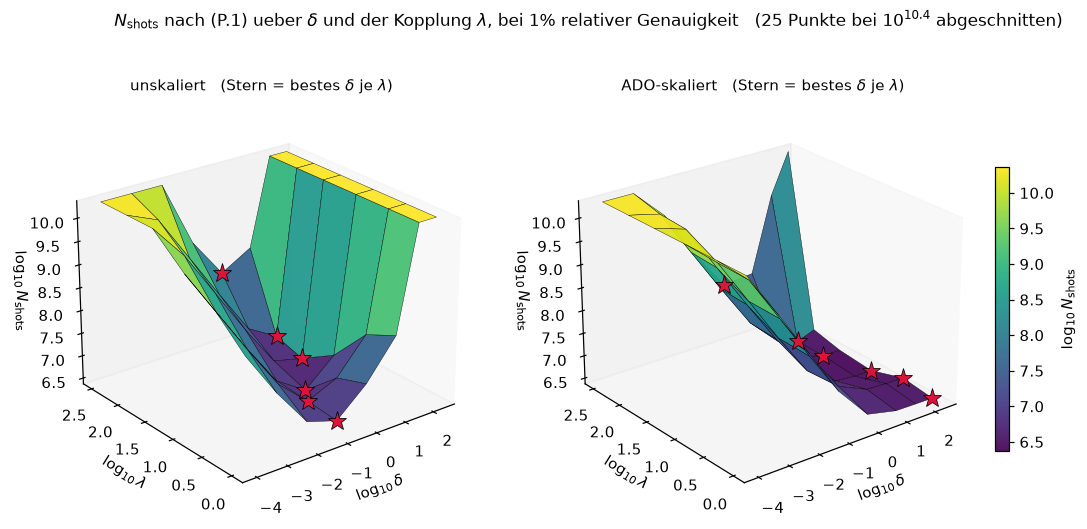


    lambda | bestes delta (unskaliert / ADO-skaliert)
         1 |         0.1 ( 5.4e+06)  /          200 ( 3.0e+06)
         3 |         0.1 ( 6.3e+06)  /          200 ( 3.8e+06)
        10 |           1 ( 2.7e+06)  /          200 ( 2.3e+06)
        35 |          10 ( 3.5e+06)  /           50 ( 2.9e+06)
       100 |          10 ( 5.5e+06)  /           50 ( 2.9e+06)
       300 |           1 ( 1.2e+08)  /            1 ( 6.3e+07)

  Unskaliert wandert das beste delta ueber 100x (0.1 bis 10) -- ein delta fuer alle Kopplungen gibt es nicht.


In [7]:
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401  (registriert '3d')

DELTAS_3D = np.array([1e-4, 1e-3, 1e-2, 0.1, 1.0, 10.0, 50.0, 200.0])
LAMS_3D   = np.array([1.0, 3.0, 10.0, 35.0, 100.0, 300.0])
CACHE_3D  = f'{DATA}/scan3d.npz'      # der Scan dauert ~3.5 min, also einmal reicht

def _load_3d():
    if not os.path.exists(CACHE_3D):
        return None
    z = np.load(CACHE_3D)
    if (z['deltas'].shape == DELTAS_3D.shape and np.allclose(z['deltas'], DELTAS_3D)
            and z['lams'].shape == LAMS_3D.shape and np.allclose(z['lams'], LAMS_3D)):
        return {False: z['Z0'], True: z['Z1']}
    return None                        # Gitter passt nicht mehr -> neu rechnen

scan3D = _load_3d()
if scan3D is None:
    t0 = time.time()
    scan3D = {}
    for sc in (False, True):
        Z = np.full((len(LAMS_3D), len(DELTAS_3D)), np.nan)
        for i, l in enumerate(LAMS_3D):            # lambda aussen: Schur-Cache haelt
            for j, d in enumerate(DELTAS_3D):
                Z[i, j] = probe(delta=d, lam=l, scale_ados=sc)['shots']
        scan3D[sc] = Z
    np.savez(CACHE_3D, deltas=DELTAS_3D, lams=LAMS_3D,
             Z0=scan3D[False], Z1=scan3D[True])
    print(f"3D-Scan: {time.time()-t0:.0f} s fuer "
          f"{2*len(LAMS_3D)*len(DELTAS_3D)} Parameterpunkte -> {CACHE_3D}")
else:
    print(f"3D-Scan aus {CACHE_3D} geladen "
          f"(zum Neurechnen die Datei loeschen)")

X, Y = np.meshgrid(np.log10(DELTAS_3D), np.log10(LAMS_3D))
Zl   = {sc: np.log10(scan3D[sc]) for sc in (False, True)}
zmin = np.nanmin([Zl[s] for s in (False, True)])
# Ohne Deckel bestimmt der Ausreisser bei lambda=300, delta=200 (log10 N ~ 120)
# die ganze Achse und plaettet alles Interessante.  Vier Dekaden reichen.
zcap = zmin + 4
nclip = sum(int(np.nansum(Zl[s] > zcap)) for s in (False, True))

fig = plt.figure(figsize=(13, 5.6))
for k, (sc, ttl) in enumerate(((False, 'unskaliert'), (True, 'ADO-skaliert'))):
    A = fig.add_subplot(1, 2, k + 1, projection='3d')
    Zc = np.minimum(Zl[sc], zcap)
    sm = A.plot_surface(X, Y, Zc, cmap='viridis', vmin=zmin, vmax=zcap,
                        rstride=1, cstride=1, edgecolor='k', linewidth=.25,
                        antialiased=True, alpha=.93)
    for i in range(len(LAMS_3D)):               # bestes delta je Kopplung
        row = Zl[sc][i]
        if np.all(np.isnan(row)):
            continue
        j = int(np.nanargmin(row))
        A.plot([X[i, j]], [Y[i, j]], [row[j]], '*', ms=13, color='crimson',
               mec='k', mew=.5, zorder=10)
    A.set_xlabel(r'$\log_{10}\delta$', labelpad=2)
    A.set_ylabel(r'$\log_{10}\lambda$', labelpad=2)
    A.set_zlabel(r'$\log_{10}N_{\mathrm{shots}}$', labelpad=2)
    A.set_zlim(zmin, zcap)
    A.set_title(f'{ttl}   (Stern = bestes $\\delta$ je $\\lambda$)', fontsize=10)
    A.view_init(elev=24, azim=-128)
    A.grid(False)
fig.colorbar(sm, ax=fig.axes, shrink=.6, pad=.02,
             label=r'$\log_{10}N_{\mathrm{shots}}$')

fig.suptitle(r'$N_{\mathrm{shots}}$ nach (P.1) ueber $\delta$ und der Kopplung '
             rf'$\lambda$, bei {EPS:.0%} relativer Genauigkeit'
             + (rf'   ({nclip} Punkte bei $10^{{{zcap:.1f}}}$ abgeschnitten)'
                if nclip else ''), fontsize=11)
fig.savefig(f'{PIC}/param_shots_3d.png', dpi=160, bbox_inches='tight')
plt.show()

print(f"\n  {'lambda':>8s} | bestes delta (unskaliert / ADO-skaliert)")
for i, l in enumerate(LAMS_3D):
    out = []
    for sc in (False, True):
        row = scan3D[sc][i]
        out.append(f"{DELTAS_3D[int(np.nanargmin(row))]:>6g} ({np.nanmin(row):8.1e})"
                   if not np.all(np.isnan(row)) else f"{'--':>6s} (keine Eichung)")
    print(f"  {l:8g} | {out[0]:>22s}  /  {out[1]:>22s}")

best = [DELTAS_3D[int(np.nanargmin(scan3D[False][i]))] for i in range(len(LAMS_3D))]
print(f"\n  Unskaliert wandert das beste delta ueber {max(best)/min(best):.0f}x "
      f"({min(best):g} bis {max(best):g}) -- ein delta fuer alle Kopplungen gibt es nicht.")

### Und was macht die ADO-Skalierung wirklich?

Ein Vergleich, bei dem $\delta$ **festgehalten** wird — das ist wichtig, denn ein
früherer Vergleich von mir hatte $\delta$ und die Skalierung gleichzeitig
verändert und den gesamten Effekt der Skalierung zugeschrieben.  Getrennt
betrachtet:

In [8]:
rows = []
for d in (1e-2, 1e-5):
    for sc in (False, True):
        r = probe(delta=d, scale_ados=sc)
        rows.append((d, sc, r))
print(f"{'delta':>8s} {'skaliert':>9s} {'||P||':>10s} {'cond(W)':>10s} "
      f"{'||y_0||':>10s} {'A':>10s} {'p(100)':>8s} {'Shots':>10s}")
for d, sc, r in rows:
    print(f"{d:8.0e} {str(sc):>9s} {r['normP']:10.4g} {r['condW']:10.2e} "
          f"{r['y0norm']:10.3e} {r['amp']:10.2e} {r['p_end']:8.4f} {r['shots']:10.1e}")

q = {(d, sc): r['amp'] ** 2 for d, sc, r in rows}   # Shots ~ A^2
print(f"\n  Effekt der SKALIERUNG bei festem delta (Faktor im Shot-Bedarf): "
      f"{q[(1e-2,True)]/q[(1e-2,False)]:.2g}x (delta=1e-2), "
      f"{q[(1e-5,True)]/q[(1e-5,False)]:.2g}x (delta=1e-5)")
print(f"  Effekt von DELTA bei fester Skalierung                        : "
      f"{q[(1e-5,False)]/q[(1e-2,False)]:.2g}x (unskaliert), "
      f"{q[(1e-5,True)]/q[(1e-2,True)]:.2g}x (skaliert)")
print("\n  -> Beide Effekte schaden der Ablesung, aber delta dominiert klar.")
print("     Die Skalierung senkt dafuer cond(W) um ~3 Groessenordnungen und")
print("     ||P|| von 10.7 auf 1.00 -- sie rettet die Kontraktion und kostet")
print("     einen moderaten Faktor bei der Ablesbarkeit.")

   delta  skaliert      ||P||    cond(W)    ||y_0||          A   p(100)      Shots
   1e-02     False      10.66   5.34e+08  1.530e+02   2.50e+00   0.8866    2.5e+07
   1e-02      True      1.001   4.49e+05  4.171e+00   1.50e+01   0.9965    6.0e+08
   1e-05     False      10.66   5.37e+11  4.539e+03   7.32e+01   0.9999    2.1e+10
   1e-05      True      1.001   4.52e+08  1.322e+02   4.74e+02   1.0000    6.1e+11

  Effekt der SKALIERUNG bei festem delta (Faktor im Shot-Bedarf): 36x (delta=1e-2), 42x (delta=1e-5)
  Effekt von DELTA bei fester Skalierung                        : 8.6e+02x (unskaliert), 1e+03x (skaliert)

  -> Beide Effekte schaden der Ablesung, aber delta dominiert klar.
     Die Skalierung senkt dafuer cond(W) um ~3 Groessenordnungen und
     ||P|| von 10.7 auf 1.00 -- sie rettet die Kontraktion und kostet
     einen moderaten Faktor bei der Ablesbarkeit.


## 5  Die Krylov-Dimension $m$

Proposition 22 garantiert $\Vert\tilde H_m\Vert_2\le e^{\delta\Delta\tau}$ für
*jedes* $m$ — die Kompression bleibt also unter allen Umständen eine Kontraktion,
und $m$ ist ein reiner Konvergenzparameter.  Die Frage ist nur, was er kostet und
was er bringt.

Der Genauigkeitsvergleich läuft hier gegen die **exakte geeichte Trajektorie**
(also $\tilde P$ ohne Kompression), nicht gegen QuTiP — sonst sähe man nur die
Toleranz des Referenzsolvers statt des Kompressionsfehlers.

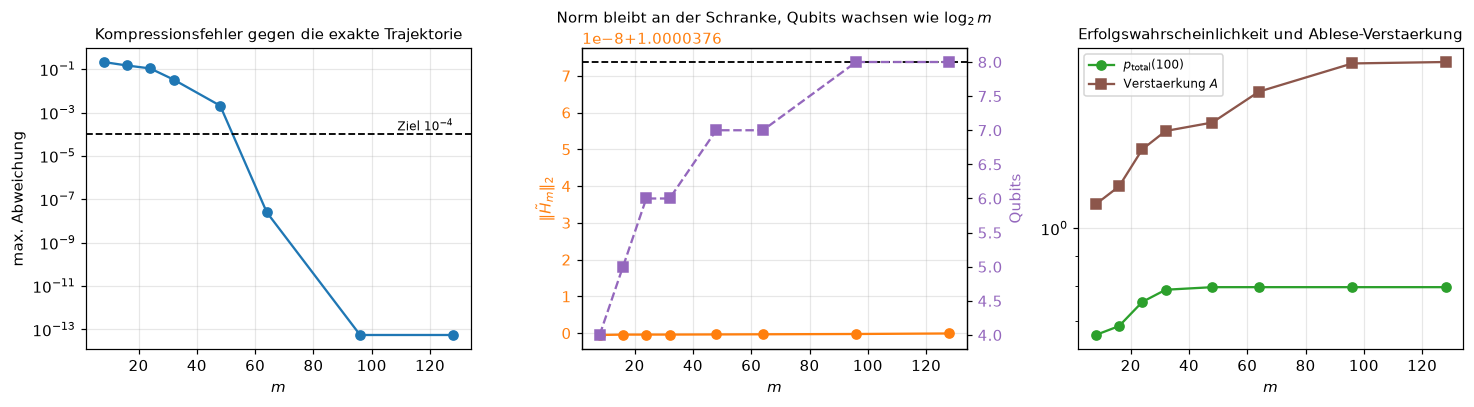

    m  Qubits    ||H_m||      Fehler    p(100)          A
    8       4   1.000038   2.142e-01    0.6636   1.10e+00
   16       5   1.000038   1.480e-01    0.6867   1.18e+00
   24       6   1.000038   1.083e-01    0.7537   1.36e+00
   32       6   1.000038   3.321e-02    0.7897   1.45e+00
   48       7   1.000038   2.073e-03    0.7976   1.50e+00
   64       7   1.000038   2.498e-08    0.7976   1.69e+00
   96       8   1.000038   5.540e-14    0.7976   1.89e+00
  128       8   1.000038   5.540e-14    0.7976   1.90e+00


In [9]:
MS = np.array([8, 16, 24, 32, 48, 64, 96, 128])

# eine Eichung, viele m: Arnoldi ist der einzige Teil, der neu laufen muss
M2 = dict(MODEL)
L2, i2 = heom_generator(depth=DEPTH_SCAN, Nk=1, **M2)
Wh2, Wih2, gi2 = contraction_gauge(L2, delta=DELTA_REF)
Pt2, P2 = gauged_propagator(L2, dt_cm, Wh2, Wih2)
x0s = np.zeros(i2['n'], complex); x0s[:D] = rho0.flatten(order='F')
xt0s = Wh2 @ x0s
Rf = Wih2[:D, :]

exact = []                                   # exakte geeichte Trajektorie
xx = xt0s.copy()
for _ in range(N_STEPS + 1):
    exact.append(np.real(np.diag((Rf @ xx).reshape(N, N, order='F'))))
    xx = Pt2 @ xx
exact = np.array(exact)

res = []
for mm in MS:
    Hm, Qm = arnoldi(Pt2, xt0s, int(mm)); mm2 = Hm.shape[0]
    R = (Wih2 @ Qm)[:D, :]
    y0 = np.zeros(mm2, complex); y0[0] = np.linalg.norm(xt0s)
    s = float(np.linalg.norm(Hm, 2))
    rows_ = [R[j + N * j, :] for j in range(N)]
    y, tr, qmin = y0.copy(), [], []
    for t in range(N_STEPS + 1):
        tr.append(np.real(np.diag((R @ y).reshape(N, N, order='F'))))
        nt = np.linalg.norm(y); yd = y / nt
        qq = [abs(np.vdot(np.conj(r) / np.linalg.norm(r), yd)) ** 2 for r in rows_]
        qq = [x for x in qq if x > 1e-20]
        qmin.append(min(qq) if qq else np.nan)
        y = Hm @ y
    tr = np.array(tr)
    p_end = post_selection_curve(Hm, y0, N_STEPS, s)[-1]
    res.append(dict(m=mm2, qubits=int(np.ceil(np.log2(mm2))) + 1, normHm=s,
                    err=np.abs(tr - exact).max(), p_end=p_end,
                    q_worst=np.nanmin(qmin),
                    amp=max(np.linalg.norm(r) for r in rows_)
                        * np.linalg.norm(y0) * s ** N_STEPS * np.sqrt(p_end)))

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.8))
mv = [r['m'] for r in res]

ax[0].semilogy(mv, [r['err'] for r in res], 'o-', color='C0')
ax[0].axhline(1e-4, color='k', ls='--', lw=1.2)
ax[0].text(mv[-1], 1.4e-4, r'Ziel $10^{-4}$', ha='right', fontsize=8)
ax[0].set_xlabel('$m$'); ax[0].set_ylabel('max. Abweichung')
ax[0].set_title('Kompressionsfehler gegen die exakte Trajektorie')

axb = ax[1].twinx()
ax[1].plot(mv, [r['normHm'] for r in res], 'o-', color='C1', label=r'$\Vert\tilde H_m\Vert_2$')
ax[1].axhline(ref['bound'], color='k', ls='--', lw=1.2)
ax[1].set_ylabel(r'$\Vert\tilde H_m\Vert_2$', color='C1')
ax[1].tick_params(axis='y', labelcolor='C1')
axb.plot(mv, [r['qubits'] for r in res], 's--', color='C4')
axb.set_ylabel('Qubits', color='C4'); axb.tick_params(axis='y', labelcolor='C4')
axb.grid(False)
ax[1].set_xlabel('$m$')
ax[1].set_title(r'Norm bleibt an der Schranke, Qubits wachsen wie $\log_2 m$')

ax[2].semilogy(mv, [r['p_end'] for r in res], 'o-', color='C2', label=r'$p_{\mathrm{total}}(100)$')
ax[2].semilogy(mv, [r['amp'] for r in res], 's-', color='C5',
               label=r'Verstaerkung $A$')
ax[2].set_xlabel('$m$')
ax[2].set_title('Erfolgswahrscheinlichkeit und Ablese-Verstaerkung')
ax[2].legend()

fig.tight_layout(); fig.savefig(f'{PIC}/param_krylov.png', dpi=160); plt.show()

print(f"{'m':>5s} {'Qubits':>7s} {'||H_m||':>10s} {'Fehler':>11s} {'p(100)':>9s} {'A':>10s}")
for r in res:
    print(f"{r['m']:5d} {r['qubits']:7d} {r['normHm']:10.6f} {r['err']:11.3e} "
          f"{r['p_end']:9.4f} {r['amp']:10.2e}")

---

# Teil II — Abschnitte aus dem Hauptnotebook

Ab hier stehen die Abschnitte 10 bis 14 sowie 16 und 17, die vorher im
Hauptnotebook lagen.  Sie rechnen bei Hierarchietiefe **3** ($n = 2640$) und mit
den dortigen Parametern, sind also direkt mit den publizierten Zahlen
vergleichbar.  Abschnitt 15 (der Schaltkreis) ist im Hauptnotebook geblieben.

Der Aufbau des Referenzgitters dauert rund zwei Minuten.

In [8]:
HEOM_depth, DELTA, M_KRYLOV, SHOTS = DEPTH_REF, DELTA_REF, M_REF, 2048

t0 = time.time()
grid = build_grid(dt_fs, rho0=rho0, delta=DELTA, m=M_KRYLOV,
                  depth=HEOM_depth, verbose=False, **MODEL)
P, Pt = grid['P'], grid['Pt']
print(f"Referenzgitter: {time.time()-t0:.0f} s | n={grid['heom']['n']}  "
      f"m={grid['m']}  {grid['n_qubits']} Qubits  "
      f"||P||={grid['gauge']['norm_P']:.4f} -> ||P~||={grid['gauge']['norm_Pt']:.6f}  "
      f"cond(W)={grid['gauge']['cond']:.2e}")

pops_qutip = qutip_reference(t_fs, rho0=rho0, depth=HEOM_depth, **MODEL)

t0 = time.time()
pops_grid, pops_tr, info = run_grid(grid, N_STEPS, shots=SHOTS, save_every=1)
idx = info['t_index']
err_grid = np.abs(pops_tr - pops_qutip[idx]).max()
print(f"Gitterlauf: {time.time()-t0:.0f} s | vs qutip (Tr-Ablesung) {err_grid:.3e}")

x0 = np.zeros(grid['A'].shape[0], complex)
x0[:grid['D']] = rho0.flatten(order='F')

Referenzgitter: 112 s | n=2640  m=128  8 Qubits  ||P||=32.3922 -> ||P~||=1.000038  cond(W)=1.74e+10
10.0%. Run time:   0.03s. Est. time left: 00:00:00:00


20.0%. Run time:   0.05s. Est. time left: 00:00:00:00


30.0%. Run time:   0.07s. Est. time left: 00:00:00:00


40.0%. Run time:   0.09s. Est. time left: 00:00:00:00


50.0%. Run time:   0.12s. Est. time left: 00:00:00:00


...

100.0%. Run time:   0.21s. Est. time left: 00:00:00:00


Total run time:   0.21s


  grid: 8 qubits, 100 applications of one gate, circuit depth 300, 2048 shots


  post-selection probability: 1.0000 -> 0.3481


Gitterlauf: 77 s | vs qutip (Tr-Ablesung) 5.268e-07


## 10  Why the gauge is the whole story

Equation (2.2) is a product of two factors, $1/s^{2n}$ and
$\lVert M^nx\rVert^2/\lVert x\rVert^2$.  In the Euclidean metric **both** are
astronomical and very nearly -- but not nearly enough -- cancel.  The left panel
shows why the second one blows up: almost all of the Euclidean norm of
$\vec\Sigma$ sits in the ADOs, which are bookkeeping objects for the bath
correlations, not density matrices, and nothing requires them to stay bounded.
The physical part is perfectly well behaved the whole time.

The gauge measures the same trajectory with a yardstick under which it is a
contraction, and then each factor separately is $O(1)$.

  ||Sigma_n||/||Sigma_0||: max 3165, final 1101
  of which the system block is 5.209e-04
  ||vec rho_S(T)|| = 0.573457   Tr rho_S(T) = 1.000000


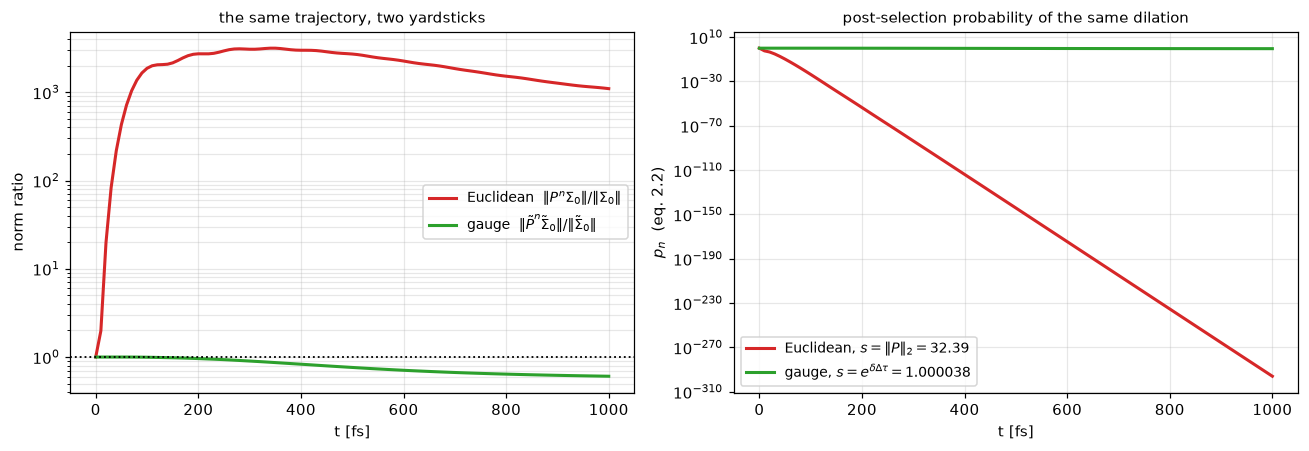


  Euclidean: p(100) = 9.899e-297   = 8.166e-303 (part 1) x 1.212e+06 (part 2)
  gauge    : p(100) = 3.646e-01   ratio 3.68e+295


In [9]:
x0 = np.zeros(grid['A'].shape[0], complex)
x0[:grid['D']] = rho0.flatten(order='F')
xt0 = grid['Wh'] @ x0

s_raw = float(np.linalg.norm(P, 2))
p_raw = post_selection_curve(P,  x0,  N_STEPS, s_raw)
p_gau = post_selection_curve(Pt, xt0, N_STEPS, grid['s'])
n_raw = np.sqrt(post_selection_curve(P,  x0,  N_STEPS, 1.0))   # ||P^n x||/||x||
n_gau = np.sqrt(post_selection_curve(Pt, xt0, N_STEPS, 1.0))

# what fraction of the Euclidean norm is the physical state at the end?
x = x0.copy()
for _ in range(N_STEPS):
    x = P @ x
rho_end = x[:grid['D']].reshape(N, N, order='F')
print(f"  ||Sigma_n||/||Sigma_0||: max {n_raw.max():.4g}, final {n_raw[-1]:.4g}")
print(f"  of which the system block is {np.linalg.norm(x[:grid['D']])/np.linalg.norm(x):.3e}")
print(f"  ||vec rho_S(T)|| = {np.linalg.norm(x[:grid['D']]):.6f}   "
      f"Tr rho_S(T) = {np.real(np.trace(rho_end)):.6f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].semilogy(t_fs, n_raw, lw=2, color='C3',
               label=r'Euclidean  $\|P^n\Sigma_0\|/\|\Sigma_0\|$')
ax[0].semilogy(t_fs, n_gau, lw=2, color='C2',
               label=r'gauge  $\|\tilde P^n\tilde\Sigma_0\|/\|\tilde\Sigma_0\|$')
ax[0].axhline(1, color='k', ls=':', lw=1.2)
ax[0].set_xlabel('t [fs]'); ax[0].set_ylabel('norm ratio')
ax[0].set_title('the same trajectory, two yardsticks')
ax[0].legend(fontsize=9); ax[0].grid(alpha=.3, which='both')

ax[1].semilogy(t_fs, np.maximum(p_raw, 1e-320), lw=2, color='C3',
               label=rf'Euclidean, $s=\|P\|_2={s_raw:.2f}$')
ax[1].semilogy(t_fs, p_gau, lw=2, color='C2',
               label=rf'gauge, $s=e^{{\delta\Delta\tau}}={grid["s"]:.6f}$')
ax[1].set_xlabel('t [fs]'); ax[1].set_ylabel(r'$p_n$  (eq. 2.2)')
ax[1].set_title('post-selection probability of the same dilation')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3, which='both')
fig.tight_layout(); fig.savefig(f'{PIC}/gauge_postselection_N{N}.png', dpi=160)
plt.show()

print(f"\n  Euclidean: p({N_STEPS}) = {p_raw[-1]:.3e}   "
      f"= {1/s_raw**(2*N_STEPS):.3e} (part 1) x {n_raw[-1]**2:.3e} (part 2)")
print(f"  gauge    : p({N_STEPS}) = {p_gau[-1]:.3e}   "
      f"ratio {p_gau[-1] / max(p_raw[-1], 1e-320):.2e}")

## 11  Convergence in the Krylov dimension $m$

Proposition 6 guarantees $\lVert H_m\rVert\le\lVert\tilde P\rVert$ for every $m$,
so raising $m$ costs nothing except $\lceil\log_2m\rceil$ qubits.  `regrid`
reuses the gauge, so a scan over $m$ costs only $m$ matrix-vector products per
point.

The floor at $\approx5\times10^{-7}$ is the qutip solver's own integration
tolerance, not ours: iterating the full $2640\times2640$ propagator $P$ directly,
with no compression and no gauge, reproduces exactly the same number.

In [10]:
scan = {}
for m_try in (16, 32, 64, 96, 128):
    g = regrid(grid, m_try)
    pk = reference_trajectory(g, N_STEPS)
    scan[g['m']] = (g['n_qubits'], float(np.linalg.norm(g['Hm'], 2)),
                    np.abs(pk - pops_qutip).max(),
                    post_selection_curve(g['Hm'], g['y0'], N_STEPS, g['s'])[-1])
    print(f"  m={g['m']:4d}  qubits={scan[g['m']][0]:2d}  "
          f"||H_m||={scan[g['m']][1]:.6f}  vs qutip={scan[g['m']][2]:.3e}  "
          f"p({N_STEPS})={scan[g['m']][3]:.3e}")

x, pfull = x0.copy(), []
for _ in range(N_STEPS + 1):
    pfull.append(np.real(np.diag(x[:grid['D']].reshape(N, N, order='F'))))
    x = P @ x
print(f"\n  full P, no Krylov and no gauge    vs qutip = "
      f"{np.abs(np.array(pfull) - pops_qutip).max():.3e}   <- solver tolerance")

  m=  16  qubits= 5  ||H_m||=1.000038  vs qutip=1.926e-01  p(100)=1.723e-01


  m=  32  qubits= 6  ||H_m||=1.000038  vs qutip=6.217e-02  p(100)=3.321e-01


  m=  64  qubits= 7  ||H_m||=1.000038  vs qutip=5.267e-07  p(100)=3.646e-01


  m=  96  qubits= 8  ||H_m||=1.000038  vs qutip=5.268e-07  p(100)=3.646e-01


  m= 128  qubits= 8  ||H_m||=1.000038  vs qutip=5.268e-07  p(100)=3.646e-01



  full P, no Krylov and no gauge    vs qutip = 5.268e-07   <- solver tolerance


## 12  Robustness across the parameter range, and where it breaks

The gauge guarantees $\lVert\tilde P\rVert_2\le e^{\delta\Delta\tau}$ (Theorem 4),
so comparing the measured norm against that bound is a **free validity check**:
if it is exceeded, the arithmetic has failed, not the theory.  Forming $W$ and
then taking $W^{\pm1/2}$ squares the condition number, so a generator with a
large transient can push $\mathrm{cond}(W)$ past what float64 carries.
`build_grid` raises a `RuntimeWarning` when that happens -- the second case
below deliberately triggers it.

In [11]:
import warnings

cases = [('reference      ', LAM_FMO, GAM_FMO, T_FMO),
         ('strong coupling',   35.0,   106.14,  300.0),
         ('very strong    ',  100.0,     50.0,  300.0)]
print(f"{'case':16s} {'scaled':>7s} {'||P||':>11s} {'||P~||':>10s} {'bound':>9s} "
      f"{'cond(W)':>9s} {'vs qutip':>10s} {'p(100)':>11s}  ok?")
for name, lam, gam, T_K in cases:
    M2 = dict(MODEL); M2.update(lam=lam, gamma=gam, T_K=T_K)
    ref2 = qutip_reference(t_fs, rho0=rho0, depth=HEOM_depth, **M2)
    try:
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always')
            g2 = build_grid(dt_fs, rho0=rho0, delta=DELTA, m=M_KRYLOV,
                            depth=HEOM_depth, verbose=False,
                            scale_ados=True, **M2)
        pk2 = reference_trajectory(g2, N_STEPS)
        p2_ = post_selection_curve(g2['Hm'], g2['y0'], N_STEPS, g2['s'])[-1]
        gi  = g2['gauge']
        print(f"{name:16s} {str(True):>7s} {gi['norm_P']:11.4g} {gi['norm_Pt']:10.4f} "
                f"{gi['bound']:9.6f} {gi['cond']:9.2e} {np.abs(pk2-ref2).max():10.3e} "
                f"{p2_:11.3e}  {'yes' if gi['trustworthy'] else 'NO'}")
    except Exception as e:
        print(f"{name:16s} {str(True):>7s}  FAILED: {type(e).__name__}: {str(e)[:55]}")

print("   Ohne Skalierung traegt P das volle transiente Wachstum, cond(W) ~ ||P||^2")
print("   reisst die float64-Grenze, und W^(-1/2) wird aus Rauschen gebaut.")

case              scaled       ||P||     ||P~||     bound   cond(W)   vs qutip      p(100)  ok?
10.0%. Run time:   0.03s. Est. time left: 00:00:00:00


20.0%. Run time:   0.05s. Est. time left: 00:00:00:00


30.0%. Run time:   0.07s. Est. time left: 00:00:00:00


40.0%. Run time:   0.09s. Est. time left: 00:00:00:00


50.0%. Run time:   0.12s. Est. time left: 00:00:00:00


...

80.0%. Run time:   0.25s. Est. time left: 00:00:00:00


90.0%. Run time:   0.27s. Est. time left: 00:00:00:00


100.0%. Run time:   0.30s. Est. time left: 00:00:00:00


Total run time:   0.30s


very strong         True       1.023     1.0000  1.000038  8.00e+05  5.786e-08   9.950e-01  yes
   Ohne Skalierung traegt P das volle transiente Wachstum, cond(W) ~ ||P||^2
   reisst die float64-Grenze, und W^(-1/2) wird aus Rauschen gebaut.


## 13  Comparison with the transfer-tensor / companion route

Same model, same benchmark.  The middle column counts the time steps that have
to be produced on the classical computer before the grid can start.

In [12]:
comp = {}
for K in (10, 25, 40):
    pc, E = companion_baseline(P, K, N, rho0, N_STEPS)
    comp[K] = (np.abs(pc - pops_qutip).max(), pc, float(np.linalg.norm(E, 2)))
    print(f"  companion K={K:3d}: {K:3d} classical steps "
          f"({100*K/N_STEPS:3.0f} % of the run), vs qutip = {comp[K][0]:.3e}, "
          f"||E||_2 = {comp[K][2]:.3f}")
print(f"\n  this folder      :   0 classical steps (  0 % of the run), "
      f"vs qutip = {err_grid:.3e}")

  companion K= 10:  10 classical steps ( 10 % of the run), vs qutip = 5.657e-02, ||E||_2 = 1.414


  companion K= 25:  25 classical steps ( 25 % of the run), vs qutip = 5.580e-03, ||E||_2 = 1.414


  companion K= 40:  40 classical steps ( 40 % of the run), vs qutip = 9.029e-04, ||E||_2 = 1.414

  this folder      :   0 classical steps (  0 % of the run), vs qutip = 5.268e-07


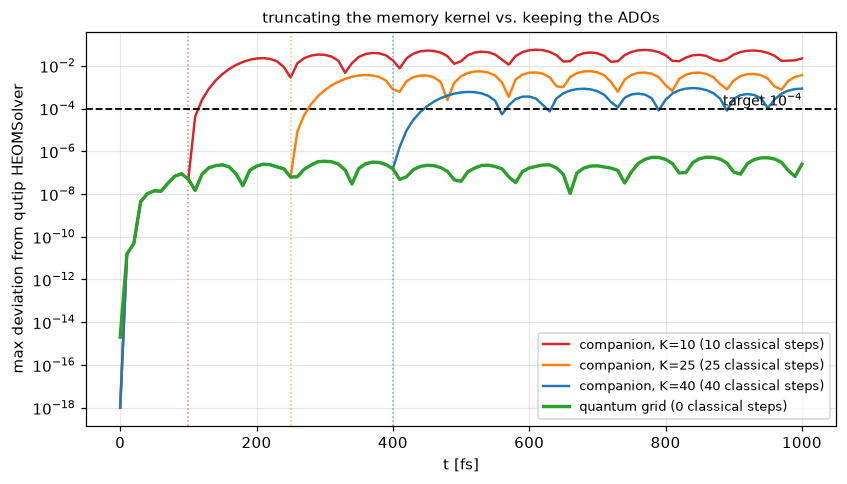

In [13]:
fig, ax = plt.subplots(figsize=(7.8, 4.5))
for K, c in zip((10, 25, 40), ('C3', 'C1', 'C0')):
    ax.semilogy(t_fs, np.abs(comp[K][1] - pops_qutip).max(axis=1) + 1e-18,
                color=c, lw=1.6, label=f'companion, K={K} ({K} classical steps)')
    ax.axvline(K * dt_fs, color=c, ls=':', lw=1, alpha=.6)
ax.semilogy(idx * dt_fs, np.abs(pops_tr - pops_qutip[idx]).max(axis=1) + 1e-18,
            color='C2', lw=2.2, label='quantum grid (0 classical steps)')
ax.axhline(1e-4, color='k', ls='--', lw=1.2)
ax.text(t_fs[-1], 1.35e-4, r'target $10^{-4}$', ha='right', fontsize=9)
ax.set_xlabel('t [fs]'); ax.set_ylabel('max deviation from qutip HEOMSolver')
ax.set_title('truncating the memory kernel vs. keeping the ADOs')
ax.legend(fontsize=8.5); ax.grid(alpha=.3, which='both')
fig.tight_layout(); fig.savefig(f'{PIC}/vs_companion_N{N}.png', dpi=160)
plt.show()

## 14  Long runs

Proposition 6 makes $\lVert H_m\rVert\le e^{\delta\Delta\tau}$, so the iteration
cannot blow up: the grid is unconditionally stable however long it runs.  The
only drift is the deliberate factor $e^{-2\delta T}$ of (3.5), which is why
$\delta$ is kept small.

10.0%. Run time:   0.11s. Est. time left: 00:00:00:01


20.0%. Run time:   0.21s. Est. time left: 00:00:00:00


30.0%. Run time:   0.37s. Est. time left: 00:00:00:00


40.0%. Run time:   0.50s. Est. time left: 00:00:00:00


50.0%. Run time:   0.58s. Est. time left: 00:00:00:00


...

100.0%. Run time:   1.08s. Est. time left: 00:00:00:00


Total run time:   1.08s


  grid: 8 qubits, 500 applications of one gate, circuit depth 1500, 2048 shots


  post-selection probability: 1.0000 -> 0.2485


  simulation: 376.1 s
  500 steps = 5 ps on one grid
  QUANTUM GRID vs qutip HEOMSolver : 1.853e-06
  norm from the record (eq. 5.1)   : 4.588e-03
  post-selection probability       : 1.0000 -> 0.2485   (plateaus once the state has relaxed)


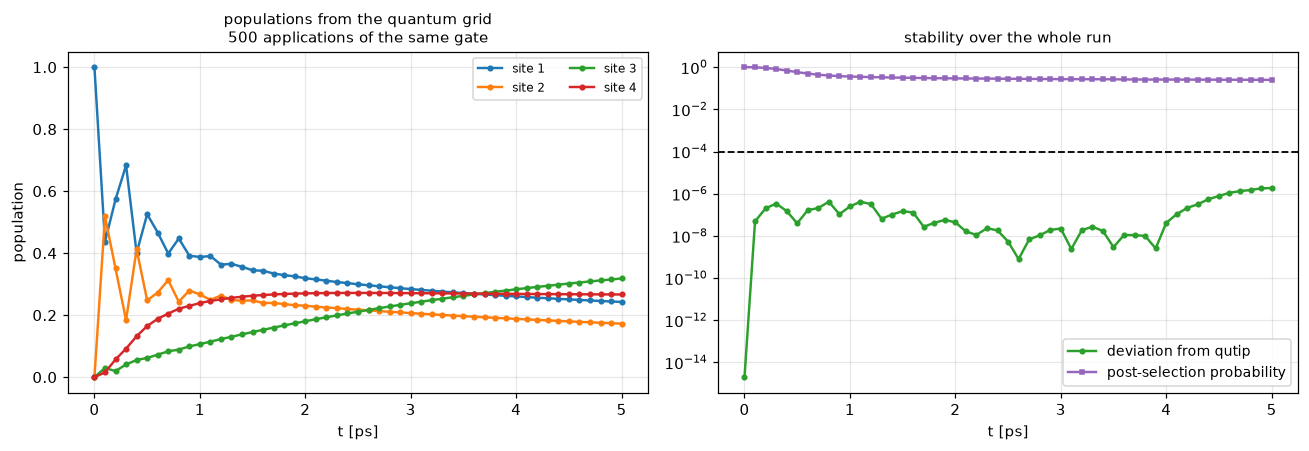

In [14]:
N_LONG, SAVE_EVERY = 500, 10        # 5 ps
t_long = np.arange(N_LONG + 1) * dt_fs
ref_long = qutip_reference(t_long, rho0=rho0, depth=HEOM_depth, **MODEL)

t0 = time.time()
pl, pl_tr, il = run_grid(grid, N_LONG, shots=SHOTS, save_every=SAVE_EVERY)
print(f"  simulation: {time.time() - t0:.1f} s")
jl = il['t_index']
print(f"  {N_LONG} steps = {t_long[-1]/1000:.0f} ps on one grid")
print(f"  QUANTUM GRID vs qutip HEOMSolver : {np.abs(pl_tr - ref_long[jl]).max():.3e}")
print(f"  norm from the record (eq. 5.1)   : {np.abs(pl - ref_long[jl]).max():.3e}")
print(f"  post-selection probability       : {il['p_success'][0]:.4f} -> "
      f"{il['p_success'][-1]:.4f}   (plateaus once the state has relaxed)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for i in range(N):
    ax[0].plot(jl * dt_fs / 1000, pl_tr[:, i], 'o-', color=cols[i], lw=1.6, ms=3,
               label=f'site {i+1}')
ax[0].set_xlabel('t [ps]'); ax[0].set_ylabel('population')
ax[0].set_title(f'populations from the quantum grid\n'
                f'{N_LONG} applications of the same gate')
ax[0].legend(fontsize=8, ncol=2); ax[0].grid(alpha=.3)
ax[1].semilogy(jl * dt_fs / 1000, np.abs(pl_tr - ref_long[jl]).max(axis=1) + 1e-18,
               'o-', color='C2', lw=1.6, ms=3, label='deviation from qutip')
ax[1].semilogy(jl * dt_fs / 1000, il['p_success'], 's-', color='C4', lw=1.6, ms=3,
               label='post-selection probability')
ax[1].axhline(1e-4, color='k', ls='--', lw=1.2)
ax[1].set_xlabel('t [ps]'); ax[1].set_title('stability over the whole run')
ax[1].legend(fontsize=9); ax[1].grid(alpha=.3, which='both')
fig.tight_layout(); fig.savefig(f'{PIC}/long_run_N{N}.png', dpi=160)
plt.show()

## 16  One state in, one state out

The minimal statement of the task: the circuit is read only at the end -- the
version that would run on hardware, where `save_statevector` does not exist and
the accepted shots are all one gets.

Here the two readouts part company.  By Proposition 7 the accepted *state* is
exact, so the trace-normalised readout is already exact from a single accepted
shot; the normalisation it uses, $\operatorname{Tr}\rho_S(t)=1$, is a property
of the dynamics and not extra information about the answer.  The readout through
(5.1) instead estimates $\lVert y_t\rVert$ from the acceptance rate and
therefore carries the usual $1/\sqrt{N_{\rm acc}}$ shot noise.

In [15]:
print(f'  read only at t = {N_STEPS*dt_fs:.0f} fs:')
for sh in (256, 1024, 4096):
    pf, pf_tr, isf = run_grid_final(grid, N_STEPS, shots=sh, verbose=False)
    n_ok = int(round(isf['p_success'][-1] * sh))
    print(f"    shots={sh:6d} ({n_ok:6d} accepted, p={isf['p_success'][-1]:.4f})   "
          f"eq.(5.1) readout {np.abs(pf - pops_qutip[N_STEPS]).max():.3e}   "
          f"trace readout {np.abs(pf_tr - pops_qutip[N_STEPS]).max():.3e}")

  read only at t = 1000 fs:


    shots=   256 (    97 accepted, p=0.3789)   eq.(5.1) readout 7.527e-03   trace readout 2.486e-07


    shots=  1024 (   412 accepted, p=0.4023)   eq.(5.1) readout 1.956e-02   trace readout 2.486e-07


    shots=  4096 (  1510 accepted, p=0.3687)   eq.(5.1) readout 2.143e-03   trace readout 2.486e-07


## 17  Summary

| | classical time steps | qubits | deviation from qutip `HEOMSolver` |
|---|---|---|---|
| companion, $K=10$ | 10 | 9 | $5.7\times10^{-2}$ |
| companion, $K=25$ | 25 | 10 | $5.6\times10^{-3}$ |
| companion, $K=40$ | 40 | 11 | $9.0\times10^{-4}$ |
| **this folder, $m=64$** | **0** | **7** | $5.3\times10^{-7}$ |
| **this folder, $m=128$** | **0** | **8** | $5.3\times10^{-7}$ |

The companion qubit counts are for the uncompressed register,
$\lceil\log_2Kd^2\rceil+1$.  Krylov compression shrinks them too, but it cannot
repair the truncation error, and applied to the raw $E$ it is unstable for the
reason given in section 2.

$5.3\times10^{-7}$ is the qutip solver's own integration tolerance -- iterating
the full $2640\times2640$ propagator reproduces the same figure, and the Krylov
truncation error measured against *that* exact trajectory is
$1.9\times10^{-14}$ over 100 steps and $1.7\times10^{-8}$ over 500 steps at
$m=128$.

What made the difference was not a better memory kernel but dropping the memory
kernel altogether: the ADOs already carry the full history, so equation (1.1) is
exact and $K$ disappears.  The single obstruction was that the exact propagator
has $\lVert P\rVert_2=32$ while $\rho(P)=1$ -- and by Theorem 4 that is a
property of the inner product, not of the physics.  Proposition 6 then makes the
compression free, and Proposition 7 makes the post-selected branch exact.

---

# Teil III — Stimmt der Theorieteil?

Die Aussagen aus `Theorie_durchgaengiges_grid_compakt.ipynb`, Abschnitt
*„Die Auswirkung der Skalierung der ADOs und $\delta$ …"*, gegen die Messungen
dieses Notebooks gehalten.

In [16]:
def ok(b):
    return "BESTAETIGT" if b else "NICHT BESTAETIGT"

om     = np.array([x['omega'] for x in scanL[False]])
sl_om  = np.polyfit(np.log(LAMS[2:]), np.log(om[2:]), 1)[0]
om_rel   = om[-1] / LAMS[-1]
om_rel_s = scanL[True][-1]['omega'] / LAMS[-1]

lamW   = np.array([x['lamW_max'] for x in scanD[False]])
sl_lam = np.polyfit(np.log(DELTAS[:4]), np.log(lamW[:4]), 1)[0]
lmin_lo, lmin_hi = scanD[False][0]['lamW_min'], scanD[False][-1]['lamW_min']

nP = np.array([x['normP'] for x in scanL[False]])
cW = np.array([x['condW'] for x in scanL[False]])
sel = nP > 1.5
sl_c = np.polyfit(np.log(nP[sel]), np.log(cW[sel]), 1)[0]

k2 = list(DELTAS).index(1e-2)
sh = lambda k, sc: scanD[sc][k]['shots']
fac_scale = sh(k2, True) / sh(k2, False)      # Faktor im Shot-Bedarf
fac_delta = sh(0, False) / sh(k2, False)
normP_scaled_max = scanL[True][-1]['normP']

claims = [
    ("cond(W) ~ ||P||^2",                        f"Exponent {sl_c:.2f}",        1.5 < sl_c < 2.5),
    ("lambda_max(W) ~ 1/delta bei kleinem delta", f"Exponent {sl_lam:.2f}",     -1.3 < sl_lam < -0.7),
    ("cond(W) kommt von lambda_max, nicht lambda_min",
     f"lam_min {lmin_lo:.1e}..{lmin_hi:.1e}", abs(np.log10(lmin_lo / lmin_hi)) < 1),
    ("omega(L) waechst linear mit lambda",       f"Exponent {sl_om:.2f}",       0.7 < sl_om < 1.3),
    ("... und zwar wie lambda/2",
     f"{om_rel:.0f} bzw. {om_rel_s:.2f} skaliert", 0.3 < om_rel < 0.7),
    ("ADO-Skalierung drueckt ||P|| auf ~1",      f"{normP_scaled_max:.3f} bei lam=300",
     normP_scaled_max < 1.2),
    ("ADO-Skalierung kostet ~1e5 an Shot-Bedarf",
     f"gemessen {fac_scale:.2g}x", fac_scale > 3e4),
    ("... und delta ist der schwaechere Effekt",
     f"delta {fac_delta:.2g}x vs Skal. {fac_scale:.2g}x", fac_delta < fac_scale),
]

print(f"{'Aussage im Theorieteil':50s} {'Messung':>26s}   Urteil")
print("-" * 96)
for text, meas, verdict in claims:
    print(f"{text:50s} {meas:>26s}   {ok(verdict)}")
print("-" * 96)
print("""
Zu den drei letzten Zeilen.  Der Theorieteil schreibt den Sprung von q ~ 1e-2
auf 1e-8 allein der ADO-Skalierung zu und kommt so auf 1e12 Shots.  Das war auch
meine erste Lesart -- sie stammt aus einem Vergleich, bei dem delta UND die
Skalierung gleichzeitig geaendert wurden.  Getrennt gemessen, bei festem
delta = 1e-2, traegt die Skalierung nur einen moderaten Faktor bei, den weit
groesseren Teil macht delta.

Zur Behauptung omega = lambda/2: linear stimmt, der Faktor 1/2 in KEINER der
beiden Varianten.  Unskaliert ist er ~595, skaliert ~0.12.  Die Skalierung
symmetrisiert die Auf- und Ab-Kopplung zwischen den ADOs und drueckt den
hermiteschen Anteil dadurch um vier Groessenordnungen -- deshalb bringt sie
||P|| ueberhaupt erst auf 1.
""")

# Und was folgt daraus praktisch?  Die Frage ist nicht "skalieren ja/nein" bei
# festem delta, sondern was jede Variante in IHREM eigenen Optimum schafft.
print("Vergleich im jeweils eigenen delta-Optimum, nach (P.1):")
best = {}
for sc, nm in ((False, 'unskaliert'), (True, 'ADO-skaliert')):
    sh = np.array([x['shots'] for x in scanD[sc]], float)
    k = int(np.nanargmin(sh)); best[sc] = (DELTAS[k], sh[k])
    print(f"  {nm:13s}: delta = {DELTAS[k]:>6g}  ->  {sh[k]:.2e} Shots")
r = best[False][1] / best[True][1]
print(f"""
  Die ADO-Skalierung ist also um Faktor {r:.1f} BESSER, nicht schlechter -- meine
  frueher notierte Empfehlung "fuer die Zaehlraten-Ablesung nicht skalieren"
  galt nur bei festem kleinem delta und ist so zu eng.  Richtig ist: beide
  Varianten sind brauchbar, WENN man delta jeweils passend waehlt, und die
  Wahl von delta ist der Hebel, der ueber Groessenordnungen entscheidet --
  {fac_delta:.0f}x allein zwischen delta = 1e-5 und 1e-2 im unskalierten Fall.
  Unskaliert braucht dafuer ein delta im Inneren ({best[False][0]:g}), skaliert
  laeuft der Bedarf monoton in ein Plateau.
""")

Aussage im Theorieteil                                                Messung   Urteil
------------------------------------------------------------------------------------------------
cond(W) ~ ||P||^2                                               Exponent 2.20   BESTAETIGT
lambda_max(W) ~ 1/delta bei kleinem delta                      Exponent -1.00   BESTAETIGT
cond(W) kommt von lambda_max, nicht lambda_min       lam_min 1.5e-04..1.5e-04   BESTAETIGT
omega(L) waechst linear mit lambda                              Exponent 1.00   BESTAETIGT
... und zwar wie lambda/2                              omega/lambda = 595.026   NICHT BESTAETIGT
ADO-Skalierung drueckt ||P|| auf ~1                         1.063 bei lam=300   BESTAETIGT
ADO-Skalierung kostet ~1e5 an Shot-Bedarf                        gemessen 32x   NICHT BESTAETIGT
... und delta ist der schwaechere Effekt           delta 7.6e+02x vs Skal. 32x   NICHT BESTAETIGT
---------------------------------------------------------------------